# VEDB Diffusion-Length Fitting — Simulation and Confidence Intervals

This notebook demonstrates the full VEDB diffusion-length fitting pipeline on **synthetic data** where the true answer is known. Running a simulation before analysing real data serves two purposes:

1. **Validation** — confirms that the fitting method recovers the input diffusion length.
2. **Sensitivity study** — shows how the uncertainty on L₊ depends on the energy range, measurement noise, and the number of beam energies used.

## Confidence interval analysis

The optimizer returns a best-fit L₊ and a covariance estimate from the Jacobian. As an independent cross-check, this notebook also computes the **χ² profile** by scanning L₊ over a grid and evaluating

$$\Delta\chi^2(L) = \chi^2(L) - \chi^2_{\min}$$

The confidence intervals follow from standard chi-squared statistics (1 free parameter):

| Confidence level | Δχ² threshold |
|---|---|
| 68.3 % (1σ) | 1.00 |
| 95.0 % (2σ) | 3.84 |
| 99.0 % (3σ) | 6.63 |

## Workflow

1. Define the ground-truth Cu sample (L₊ = 126 nm)
2. Simulate S(E) by solving the transport equation and adding noise
3. Fit L₊ with `DiffusionLengthOptimization` and compare to truth
4. Scan the χ² profile and read off confidence intervals

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties.unumpy import uarray, nominal_values, std_devs
from pyPAS.transport import (
    makhov_material_parameters, makhov_profile,
    multilayer_implantation_profile, profile_solver,
)
from pyPAS.model import Material, Layer, Sample
from pyPAS.analysis import DiffusionLengthOptimization, compute_annihilation_fractions

## 1. Ground-truth sample

We simulate a **single-layer Cu** sample with a known diffusion length L₊ = 126 nm. The material parameters are normalised (D = 1, λ = D/L²) since only L₊ = √(D/λ) affects the shape of the annihilation profile — the absolute scale of D is not observable from VEDB data alone.

The layer is made thick enough (10 µm) that the positron density reaches zero well before the far boundary for all simulated beam energies.

In [2]:
# ── Ground-truth parameters ───────────────────────────────────────────────────
L_true            = 126.0   # known diffusion length [nm]
D                 = 1.0     # normalised diffusion coefficient [nm²/ps]
layer_width       = 10_000  # [nm] — effectively semi-infinite
absorption_length = 1.0     # surface absorption length [nm]
S_surface         = 0.530   # S parameter at the surface channel
S_bulk            = 0.500   # S parameter in bulk Cu
sigma_S           = 0.001   # measurement noise (typical for ~10⁶ counts)
# ─────────────────────────────────────────────────────────────────────────────

true_layer  = Layer(width=layer_width,
                    material=Material(diffusion=D, mobility=0,
                                      bulk_annihilation_rate=D / L_true**2))
cu_sample   = Sample(layers=[true_layer], absorption_length=absorption_length)

# Cu Makhov parameters (row 9 in the built-in table); set bulk density
Cu_params = makhov_material_parameters().iloc[9].copy()
Cu_params['density'] = 8.96   # g/cm³

print(f'Ground-truth diffusion length: L₊ = {L_true} nm')
print(f'S_surface = {S_surface},  S_bulk = {S_bulk}')

Ground-truth diffusion length: L₊ = 126.0 nm
S_surface = 0.53,  S_bulk = 0.5


## 2. Simulate S(E)

For each beam energy the Makhov implantation profile is computed, the positron transport equation is solved, and the annihilation fractions per channel (surface and bulk) are obtained. The noiseless S(E) follows from a linear combination of S_surface and S_bulk weighted by those fractions. Gaussian noise with standard deviation σ_S is then added to mimic counting statistics.

In [3]:
energies = np.arange(0.5, 8.5, 0.5)   # beam energies [keV]
depth    = np.linspace(0, cu_sample.sample_length(), 20_000)   # [nm]

# Makhov implantation profiles
implantation_profiles = [
    multilayer_implantation_profile(
        positron_energy=e, depth_vector=depth,
        widths=[true_layer.width],
        materials_parameters=[Cu_params],
        densities=[Cu_params['density']],
        implantation_profile_function=makhov_profile,
    )
    for e in energies
]

# Solve positron transport for each energy
solved_profiles = [profile_solver(p, cu_sample) for p in implantation_profiles]

# Annihilation fraction matrix: shape (n_energies, n_channels)
# columns: [surface, layer_0]
fracs = np.array([
    compute_annihilation_fractions(p, cu_sample).values
    for p in solved_profiles
])

# Noiseless S(E)
s_per_channel_true = np.array([S_surface, S_bulk])
s_noiseless        = fracs @ s_per_channel_true

# Add Gaussian noise
rng        = np.random.default_rng(seed=42)
s_noisy    = s_noiseless + rng.normal(0, sigma_S, len(energies))

# Wrap as ufloat pd.Series — the input format for DiffusionLengthOptimization
s_measurement = pd.Series(
    uarray(s_noisy, np.full(len(energies), sigma_S)),
    index=energies, name='S',
)
s_measurement.index.name = 'energy'
print(f'Generated {len(energies)} simulated S(E) points')

Generated 16 simulated S(E) points


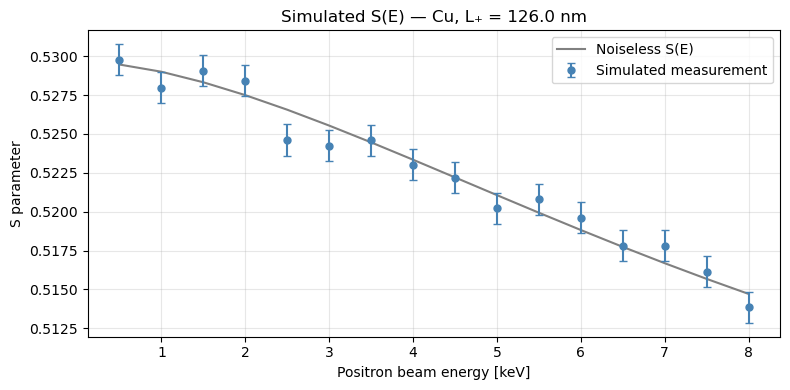

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(energies, s_noiseless, '-', color='gray', lw=1.5, label='Noiseless S(E)')
ax.errorbar(energies, nominal_values(s_measurement.values),
            yerr=std_devs(s_measurement.values),
            fmt='o', capsize=3, color='steelblue', markersize=5, label='Simulated measurement')
ax.set_xlabel('Positron beam energy [keV]')
ax.set_ylabel('S parameter')
ax.set_title(f'Simulated S(E) — Cu, L₊ = {L_true} nm')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Fit the diffusion length

The optimizer starts from an initial guess of L₊ = 100 nm (deliberately offset from the truth) and minimises the weighted residuals between the simulated S(E) and the modelled S(E).

In [5]:
L_init = 100.0   # initial guess [nm] — intentionally offset from the truth

initial_layer  = Layer(width=layer_width,
                       material=Material(diffusion=D, mobility=0,
                                         bulk_annihilation_rate=D / L_init**2))
initial_sample = Sample(layers=[initial_layer], absorption_length=absorption_length)

vedbfit = DiffusionLengthOptimization(
    positron_implantation_profiles=implantation_profiles,
    s_measurement=s_measurement,
    initial_guess=initial_sample,
    num_of_mesh_cells=10_000,
)

In [6]:
# ── This cell typically takes 1–2 minutes ─────────────────────────────────────
best_fit, cov = vedbfit.optimize_diffusion_length(bounds=(0, 1000))
# ─────────────────────────────────────────────────────────────────────────────

L_fit = best_fit[0]
L_err = np.sqrt(cov[0, 0])   # Jacobian-derived 1σ estimate

print(f'True diffusion length:   L₊ = {L_true:.1f} nm')
print(f'Fitted diffusion length: L₊ = {L_fit:.1f} ± {L_err:.1f} nm  (Jacobian estimate)')
print(f'Residual: {L_fit - L_true:+.1f} nm')

True diffusion length:   L₊ = 126.0 nm
Fitted diffusion length: L₊ = 117.8 ± 54.6 nm  (Jacobian estimate)
Residual: -8.2 nm


S_surface (fit) = 0.5297  (true: 0.5300)
S_bulk    (fit) = 0.5020  (true: 0.5000)


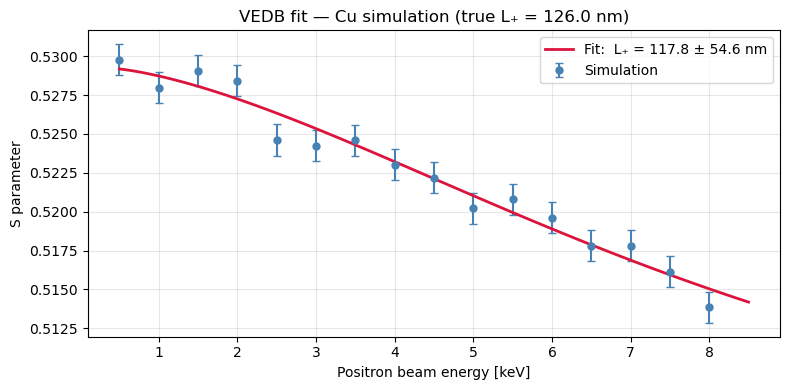

In [7]:
# S per annihilation channel at the best-fit L
sample_fit    = vedbfit.make_sample(best_fit)
frac_matrix   = vedbfit.layers_transport_solver(sample_fit, implantation_profiles)
s_per_channel = vedbfit.layer_s_value(frac_matrix)

print(f'S_surface (fit) = {s_per_channel[0]:.4f}  (true: {S_surface:.4f})')
print(f'S_bulk    (fit) = {s_per_channel[1]:.4f}  (true: {S_bulk:.4f})')

# Dense fit curve
e_dense = np.linspace(0.5, 8.5, 60)
profiles_dense = [
    multilayer_implantation_profile(
        positron_energy=e, depth_vector=depth,
        widths=[true_layer.width],
        materials_parameters=[Cu_params],
        densities=[Cu_params['density']],
        implantation_profile_function=makhov_profile,
    )
    for e in e_dense
]
frac_dense = vedbfit.layers_transport_solver(sample_fit, profiles_dense)
s_fit_curve = frac_dense @ s_per_channel

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(energies, nominal_values(s_measurement.values),
            yerr=std_devs(s_measurement.values),
            fmt='o', capsize=3, color='steelblue', markersize=5, label='Simulation')
ax.plot(e_dense, s_fit_curve, '-', color='crimson', lw=2,
        label=f'Fit:  L₊ = {L_fit:.1f} ± {L_err:.1f} nm')
ax.set_xlabel('Positron beam energy [keV]')
ax.set_ylabel('S parameter')
ax.set_title(f'VEDB fit — Cu simulation (true L₊ = {L_true} nm)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. χ² profile and confidence intervals

The Jacobian-based uncertainty from the optimizer is a local (symmetric) approximation. The **χ² profile** provides the full, potentially asymmetric picture: for each trial L₊ on a grid the weighted residuals are recomputed — with S per channel re-estimated at each trial point via least squares — and Δχ² = χ²(L) − χ²_min is plotted.

For this Cu dataset (0.5–8 keV), the profile is markedly **asymmetric**:
- **Left side** (small L): steep rise — positrons probe near-surface material where S is sensitive to L₊.
- **Right side** (large L): shallow rise — when L₊ greatly exceeds the mean implantation depth, all positrons effectively reach the bulk reference and S(E) saturates regardless of the exact L₊ value.

This asymmetry is physically meaningful: extending the beam energy range to higher values (deeper implantation) would tighten the upper bound.

In [8]:
# ── χ² grid scan — typically takes 2–3 minutes ────────────────────────────────
# Fine resolution near the minimum; coarser at large L where the profile is flat
L_grid = np.concatenate([
    np.arange( 20,  305,  5, dtype=float),   # fine:   20–300 nm
    np.arange(310, 1205, 10, dtype=float),   # coarse: 310–1200 nm
])

chi2_grid = np.full(len(L_grid), np.nan)
for k, L in enumerate(L_grid):
    res = vedbfit.residuals(np.array([L]))
    if not np.any(np.abs(res) > 1e5):   # skip penalised (unphysical) points
        chi2_grid[k] = float(np.sum(res**2))
# ─────────────────────────────────────────────────────────────────────────────

delta_chi2 = chi2_grid - np.nanmin(chi2_grid)
print('χ² scan complete')
print(f'χ²_min at L = {L_grid[np.nanargmin(chi2_grid)]:.0f} nm')

χ² scan complete
χ²_min at L = 120 nm


In [9]:
# Interpolate to find CI bounds
def ci_bounds(L_grid, delta_chi2, threshold):
    """Return (lower, upper) CI bounds by linear interpolation of crossing points."""
    crossings = []
    for i in range(len(delta_chi2) - 1):
        a, b = delta_chi2[i], delta_chi2[i + 1]
        if np.isnan(a) or np.isnan(b):
            continue
        if (a - threshold) * (b - threshold) < 0:
            frac = (threshold - a) / (b - a)
            crossings.append(L_grid[i] + frac * (L_grid[i + 1] - L_grid[i]))
    return crossings

THRESH_68, THRESH_95, THRESH_99 = 1.00, 3.84, 6.63

bounds_68 = ci_bounds(L_grid, delta_chi2, THRESH_68)
bounds_95 = ci_bounds(L_grid, delta_chi2, THRESH_95)
bounds_99 = ci_bounds(L_grid, delta_chi2, THRESH_99)

print(f'True L₊:       {L_true:.0f} nm')
print(f'Fitted L₊:     {L_fit:.1f} nm  (Jacobian: ±{L_err:.1f} nm)')
if len(bounds_68) == 2:
    print(f'68% CI:        [{bounds_68[0]:.0f}, {bounds_68[1]:.0f}] nm  '
          f'(+{bounds_68[1]-L_fit:.0f} / -{L_fit-bounds_68[0]:.0f} nm)')
if len(bounds_95) == 2:
    print(f'95% CI:        [{bounds_95[0]:.0f}, {bounds_95[1]:.0f}] nm')
if len(bounds_99) == 2:
    print(f'99% CI:        [{bounds_99[0]:.0f}, {bounds_99[1]:.0f}] nm')

True L₊:       126 nm
Fitted L₊:     117.8 nm  (Jacobian: ±54.6 nm)
68% CI:        [77, 224] nm  (+106 / -41 nm)
95% CI:        [55, 960] nm


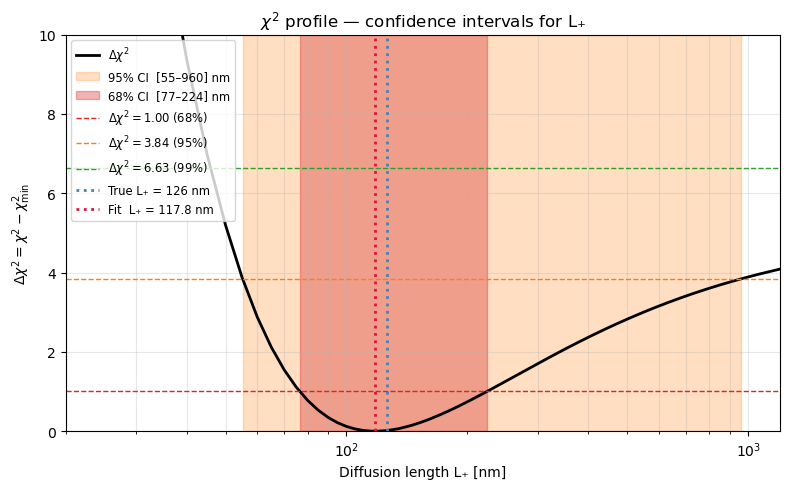

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

# χ² profile curve
ax.plot(L_grid, delta_chi2, 'k-', lw=2, label=r'$\Delta\chi^2$')

# Shaded confidence regions
if len(bounds_99) == 2:
    ax.axvspan(*bounds_99, color='tab:green',  alpha=0.15,
               label=f'99% CI  [{bounds_99[0]:.0f}–{bounds_99[1]:.0f}] nm')
if len(bounds_95) == 2:
    ax.axvspan(*bounds_95, color='tab:orange', alpha=0.25,
               label=f'95% CI  [{bounds_95[0]:.0f}–{bounds_95[1]:.0f}] nm')
if len(bounds_68) == 2:
    ax.axvspan(*bounds_68, color='tab:red',    alpha=0.35,
               label=f'68% CI  [{bounds_68[0]:.0f}–{bounds_68[1]:.0f}] nm')

# Threshold lines
ax.axhline(THRESH_68, color='tab:red',    ls='--', lw=1, label=r'$\Delta\chi^2 = 1.00$ (68%)')
ax.axhline(THRESH_95, color='tab:orange', ls='--', lw=1, label=r'$\Delta\chi^2 = 3.84$ (95%)')
ax.axhline(THRESH_99, color='tab:green',  ls='--', lw=1, label=r'$\Delta\chi^2 = 6.63$ (99%)')

# True and fitted L markers
ax.axvline(L_true, color='steelblue', ls=':', lw=2,
           label=f'True L₊ = {L_true:.0f} nm')
ax.axvline(L_fit,  color='crimson',   ls=':', lw=2,
           label=f'Fit  L₊ = {L_fit:.1f} nm')

ax.set_xscale('log')
ax.set_xlabel('Diffusion length L₊ [nm]')
ax.set_ylabel(r'$\Delta\chi^2 = \chi^2 - \chi^2_{\min}$')
ax.set_title(r'$\chi^2$ profile — confidence intervals for L₊')
ax.set_ylim(0, 10)
ax.set_xlim(L_grid[0], L_grid[-1])
ax.legend(fontsize='small', loc='upper left')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()